# Pairs Trading — Statistical Arbitrage

Pairs trading exploits the **cointegration** between two related assets. When two prices drift apart more than their historical relationship would predict, we sell the expensive one and buy the cheap one, betting the spread will revert.

Unlike directional strategies, pairs trading is **market-neutral**: one leg is always long, the other short, so broad market moves largely cancel out.

QuantCore's `PairsTrading` strategy tracks the log-spread `log(P1 / P2)`, computes a rolling z-score, and trades when the z-score exceeds a threshold.

---

## Contents
1. Setup & correlated asset simulation
2. Spread analysis & cointegration intuition
3. Baseline backtest
4. Performance tearsheet
5. Sensitivity to entry z-score and lookback
6. Pair correlation breakdown — regime risk

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import quantcore as qc
from quantcore.analytics import calculate_all_metrics, calculate_returns
from quantcore.plotting import plot_full_tearsheet


def strip_sentinel(results: dict) -> tuple:
    """Strip the zero-timestamp sentinel the engine prepends to the equity curve.

    The C++ engine inserts timestamps_[0] = 0 (Unix epoch) before the first
    bar is processed. Keeping it causes the x-axis to span 1970-present and
    inflates annualisation calculations.
    """
    equity = np.array(results['equity_curve'])
    ts     = np.array(results['timestamps'], dtype='int64')

    # drop every leading entry whose timestamp is zero (the sentinel)
    first_real = np.argmax(ts > 0)
    return equity[first_real:], ts[first_real:]


print(f'QuantCore {qc.version()}')

QuantCore 0.1.0


## 1. Simulating a Cointegrated Pair

We construct two price series that share a common stochastic trend (a random walk), with independent idiosyncratic noise added to each. This is the textbook definition of cointegration — the spread is stationary even though each individual series is a random walk.

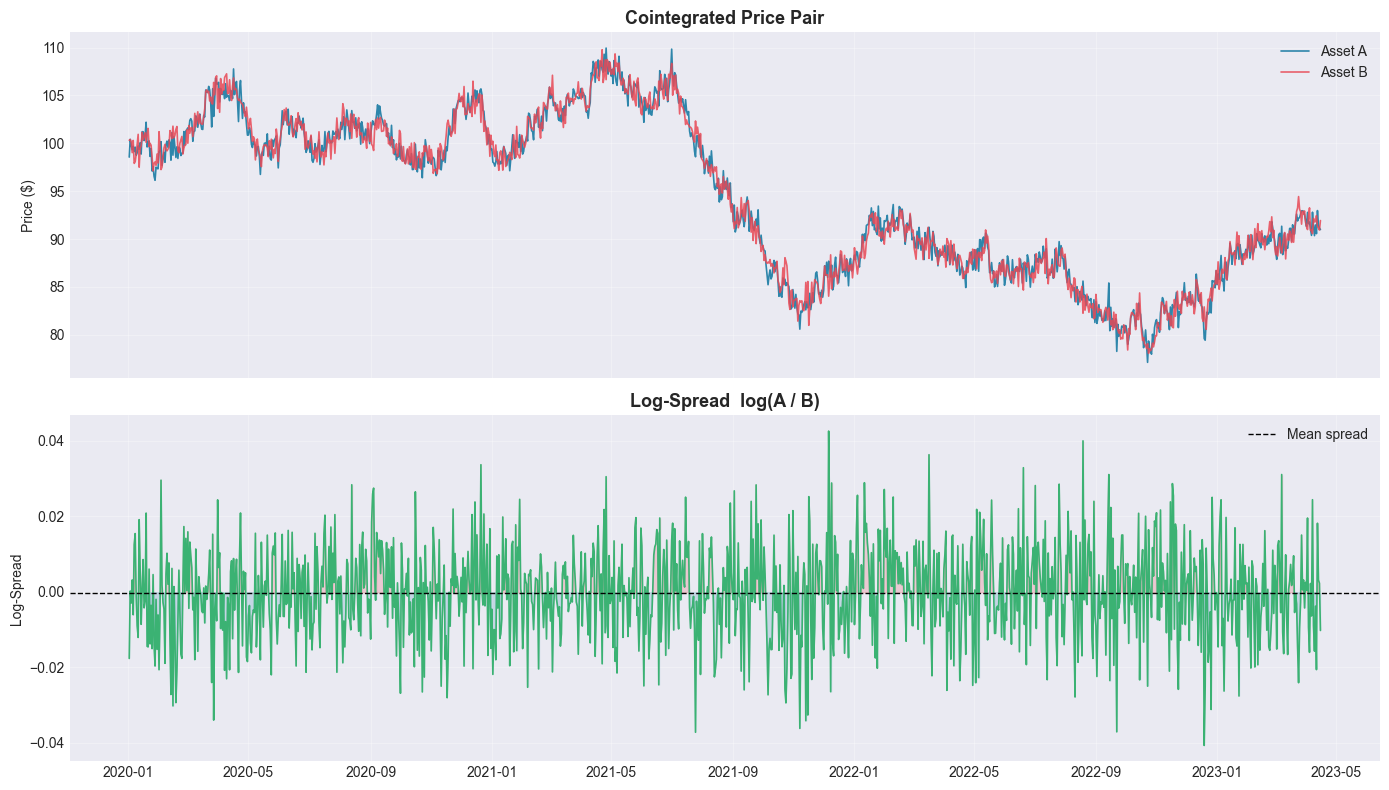

In [2]:
np.random.seed(21)

N = 1200

# shared trend (random walk — makes each series individually non-stationary)
common_trend = np.cumsum(np.random.randn(N) * 0.5)

# idiosyncratic noise for each leg
noise1 = np.random.randn(N) * 0.8
noise2 = np.random.randn(N) * 0.8

# both prices follow the same trend, spread is mean-reverting
prices1 = 100.0 + common_trend + noise1
prices2 = 100.0 + common_trend + noise2
prices1 = np.maximum(prices1, 10.0)
prices2 = np.maximum(prices2, 10.0)

start_ns   = int(pd.Timestamp('2020-01-02').value)
day_ns     = int(pd.Timedelta('1D').value)
timestamps = [start_ns + i * day_ns for i in range(N)]

bars_a = [
    qc.BarData('ASSET_A', timestamps[i], prices1[i],
               prices1[i] + abs(np.random.randn() * 0.2),
               prices1[i] - abs(np.random.randn() * 0.2),
               prices1[i], 1_000_000.0)
    for i in range(N)
]

bars_b = [
    qc.BarData('ASSET_B', timestamps[i], prices2[i],
               prices2[i] + abs(np.random.randn() * 0.2),
               prices2[i] - abs(np.random.randn() * 0.2),
               prices2[i], 1_000_000.0)
    for i in range(N)
]

dates     = pd.to_datetime(timestamps, unit='ns')
log_spread = np.log(prices1 / prices2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(dates, prices1, linewidth=1.2, color='#2E86AB', label='Asset A')
axes[0].plot(dates, prices2, linewidth=1.2, color='#E84855', label='Asset B', alpha=0.85)
axes[0].set_title('Cointegrated Price Pair', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(dates, log_spread, linewidth=1.2, color='#3BB273')
axes[1].axhline(log_spread.mean(), color='black', linestyle='--', linewidth=1, label='Mean spread')
axes[1].fill_between(dates, log_spread, log_spread.mean(),
                     where=log_spread > log_spread.mean(), alpha=0.2, color='#E84855')
axes[1].fill_between(dates, log_spread, log_spread.mean(),
                     where=log_spread < log_spread.mean(), alpha=0.2, color='#2E86AB')
axes[1].set_title('Log-Spread  log(A / B)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log-Spread')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Spread Analysis

Before trading, we verify the spread looks stationary — non-stationarity would invalidate the mean-reversion assumption.

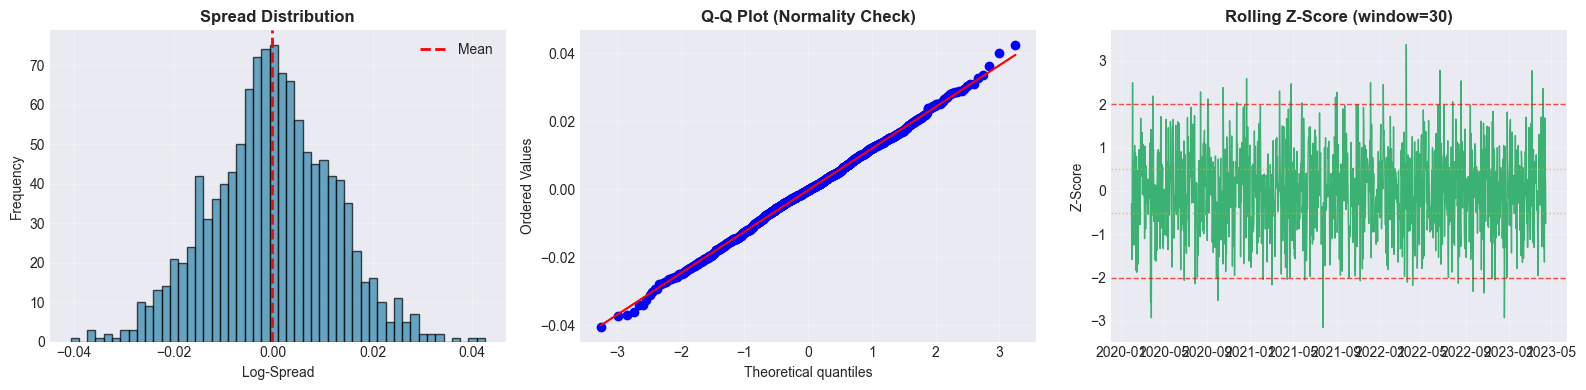

Spread mean:     -0.0003
Spread std:      0.0122
Spread skew:     -0.0194
Spread kurtosis: 0.1138
Price correlation: 0.9902


In [3]:
spread_series = pd.Series(log_spread, index=dates)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# spread distribution
axes[0].hist(log_spread, bins=50, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].axvline(log_spread.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].set_title('Spread Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Log-Spread')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot — how normal is the spread?
stats.probplot(log_spread, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# rolling z-score
lookback      = 30
rolling_mean  = spread_series.rolling(lookback).mean()
rolling_std   = spread_series.rolling(lookback).std()
z_score       = (spread_series - rolling_mean) / rolling_std

axes[2].plot(dates, z_score, linewidth=1.0, color='#3BB273')
for level, style in [(2.0, '--'), (-2.0, '--'), (0.5, ':'), (-0.5, ':')]:
    axes[2].axhline(level, color='red' if abs(level) > 1 else 'orange',
                    linestyle=style, linewidth=1, alpha=0.7)
axes[2].set_title(f'Rolling Z-Score (window={lookback})', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Z-Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# summary statistics
print(f'Spread mean:     {log_spread.mean():.4f}')
print(f'Spread std:      {log_spread.std():.4f}')
print(f'Spread skew:     {stats.skew(log_spread):.4f}')
print(f'Spread kurtosis: {stats.kurtosis(log_spread):.4f}')

# correlation between the two assets
corr = np.corrcoef(prices1, prices2)[0, 1]
print(f'Price correlation: {corr:.4f}')

## 3. Baseline Backtest

In [4]:
INITIAL_CAPITAL = 100_000.0

strategy = qc.PairsTrading(
    symbol1='ASSET_A',
    symbol2='ASSET_B',
    lookback=30,
    entry_zscore=2.0,
    exit_zscore=0.5,
)

# pairs trading requires both symbols in the same engine
results = qc.run_backtest(
    strategy=strategy,
    data={'ASSET_A': bars_a, 'ASSET_B': bars_b},
    initial_capital=INITIAL_CAPITAL,
)

equity_curve, ts = strip_sentinel(results)
returns          = calculate_returns(equity_curve)
metrics          = calculate_all_metrics(equity_curve, risk_free_rate=0.0)

print(metrics)

  Performance Metrics

Returns:
  Total Return:                  9.94%
  Annualized Return:             1.00%

Risk Metrics:
  Sharpe Ratio:                  1.04
  Sortino Ratio:                 1.08
  Volatility:                    0.96%
  Max Drawdown:                 -0.37%
  Max DD Duration:                 59 days
  Calmar Ratio:                  2.68

Trading Metrics:
  Total Trades:                     0
  Win Rate:                      0.00%
  Profit Factor:                 0.00
  Average Win:           $       0.00
  Average Loss:          $       0.00
  Largest Win:           $       0.00
  Largest Loss:          $       0.00



## 4. Performance Tearsheet

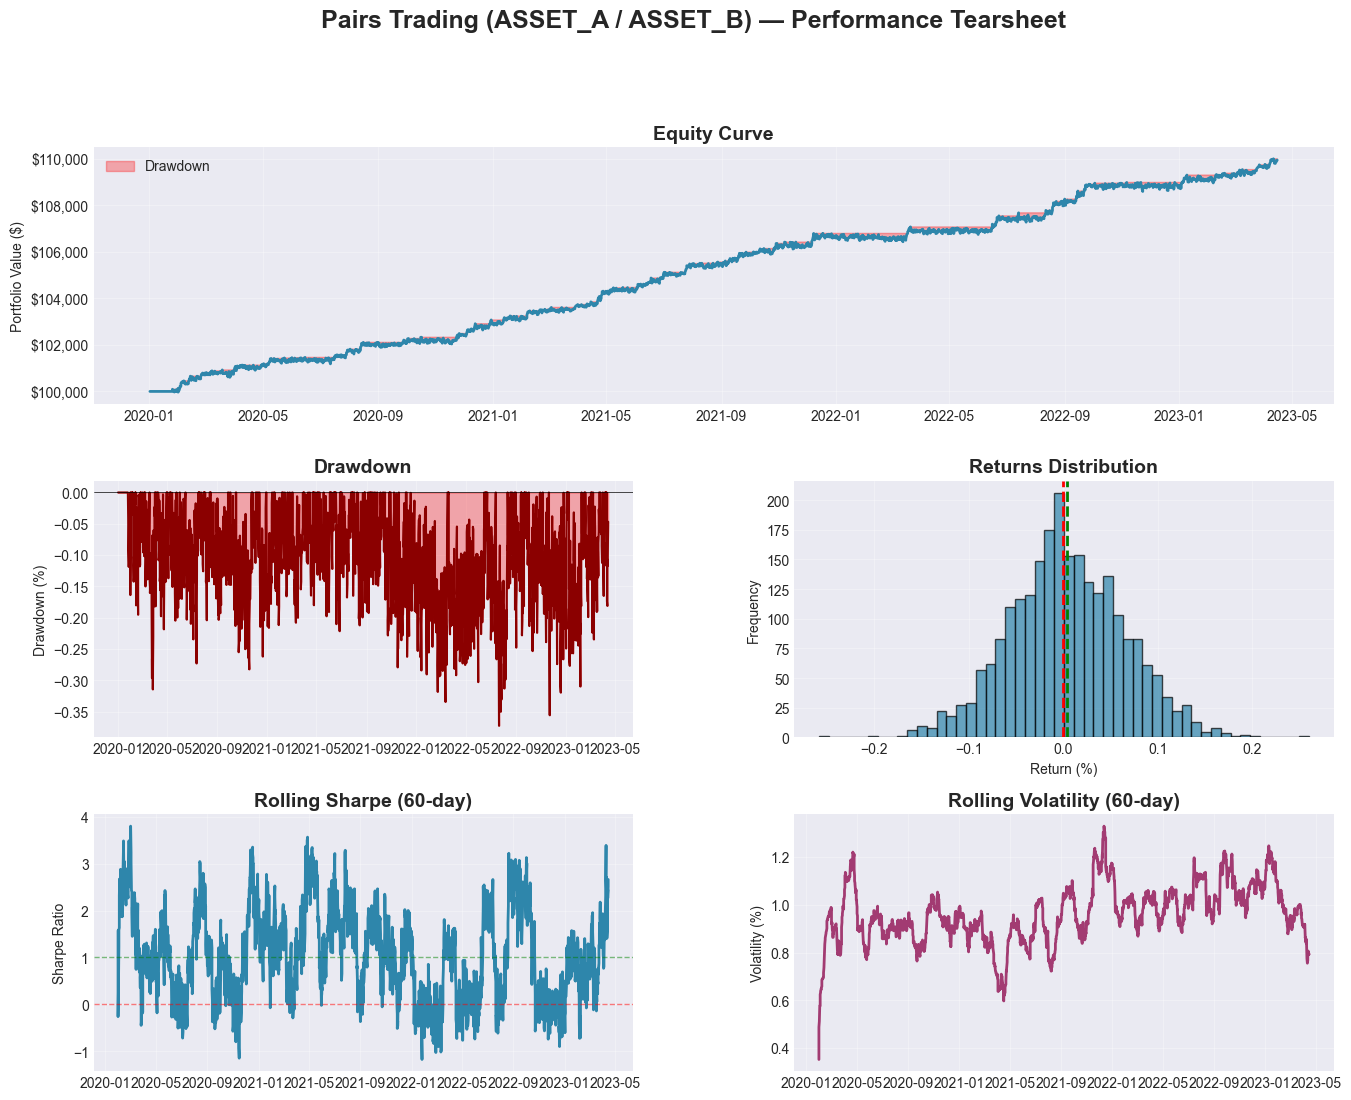

In [5]:
fig = plot_full_tearsheet(
    equity_curve,
    returns,
    timestamps=ts,
    title='Pairs Trading (ASSET_A / ASSET_B) — Performance Tearsheet',
)
plt.show()

## 5. Sensitivity to Entry Z-Score and Lookback

Higher entry z-score = fewer, higher-conviction trades. Shorter lookback = faster adaptation to regime changes but noisier z-scores.

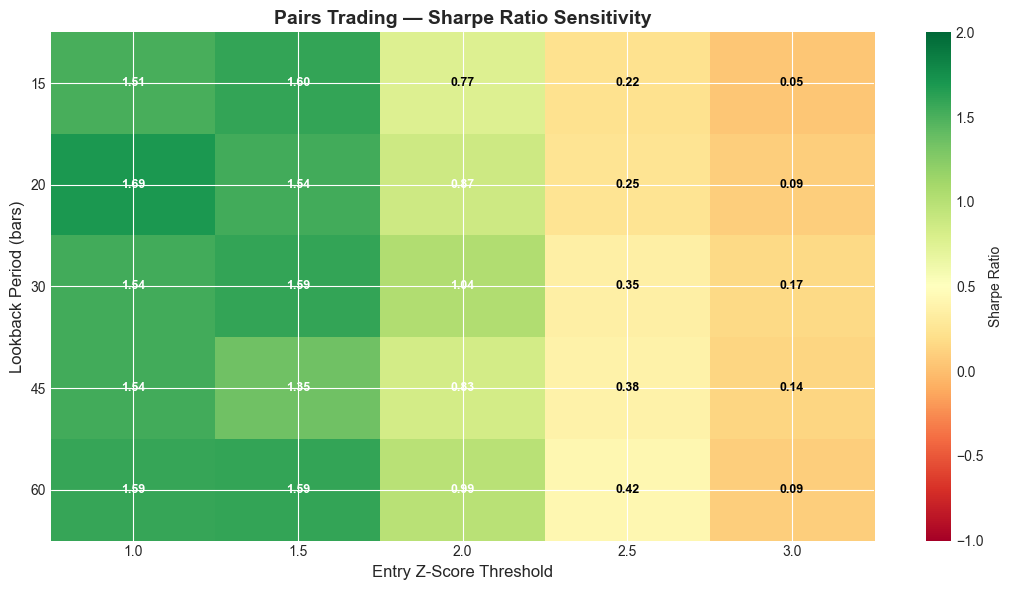

In [6]:
entry_zscores = [1.0, 1.5, 2.0, 2.5, 3.0]
lookbacks     = [15, 20, 30, 45, 60]

sharpe_grid = np.full((len(lookbacks), len(entry_zscores)), np.nan)

for i, lb in enumerate(lookbacks):
    for j, ez in enumerate(entry_zscores):
        s = qc.PairsTrading(
            symbol1='ASSET_A', symbol2='ASSET_B',
            lookback=lb, entry_zscore=ez, exit_zscore=ez * 0.25,
        )
        r      = qc.run_backtest(strategy=s, data={'ASSET_A': bars_a, 'ASSET_B': bars_b},
                                 initial_capital=INITIAL_CAPITAL)
        ec, _  = strip_sentinel(r)
        if len(ec) > 1:
            m = calculate_all_metrics(ec, risk_free_rate=0.0)
            # clamp to [-3, 3] — values outside this range indicate near-zero
            # volatility (no/few trades) rather than real signal quality
            sharpe_grid[i, j] = np.clip(m.sharpe_ratio, -3.0, 3.0)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(sharpe_grid, aspect='auto', cmap='RdYlGn', vmin=-1.0, vmax=2.0)

ax.set_xticks(range(len(entry_zscores)))
ax.set_xticklabels([str(v) for v in entry_zscores])
ax.set_yticks(range(len(lookbacks)))
ax.set_yticklabels([str(v) for v in lookbacks])
ax.set_xlabel('Entry Z-Score Threshold', fontsize=12)
ax.set_ylabel('Lookback Period (bars)', fontsize=12)
ax.set_title('Pairs Trading — Sharpe Ratio Sensitivity', fontsize=14, fontweight='bold')

for i in range(len(lookbacks)):
    for j in range(len(entry_zscores)):
        if not np.isnan(sharpe_grid[i, j]):
            color = 'white' if abs(sharpe_grid[i, j]) > 0.8 else 'black'
            ax.text(j, i, f'{sharpe_grid[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Sharpe Ratio')
plt.tight_layout()
plt.show()

## 6. Pair Correlation Breakdown — Regime Risk

The biggest risk in pairs trading is that the pair **decouples** — the shared trend breaks down and the spread becomes non-stationary. We simulate this by introducing a structural break midway through the sample.

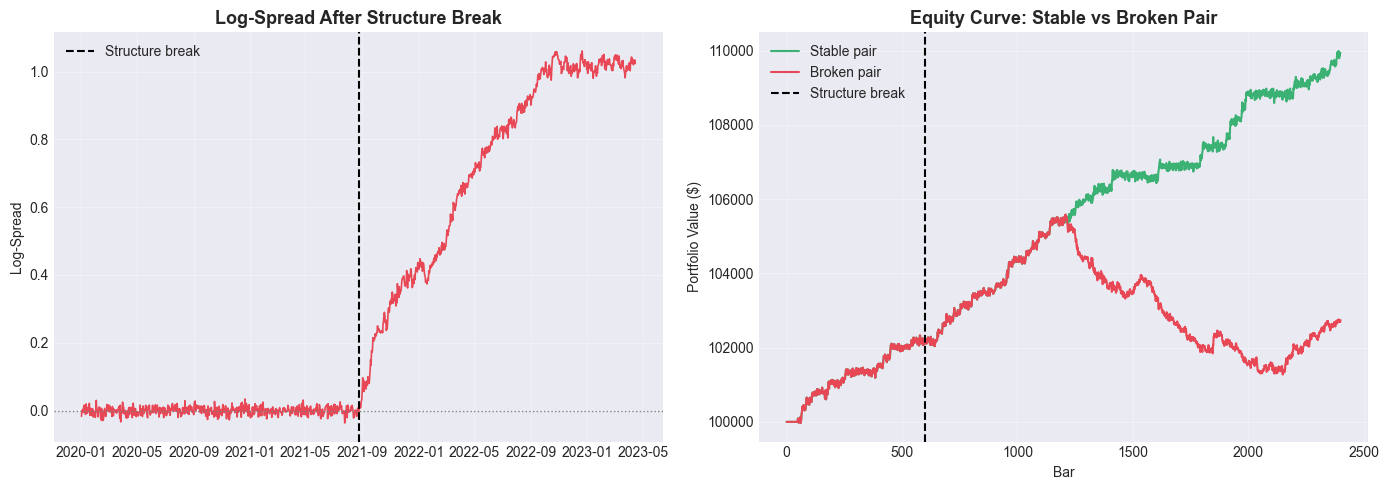

Stable pair — Sharpe: 1.04  Max DD: -0.4%
Broken pair — Sharpe: 0.34  Max DD: -4.1%

Takeaway: when cointegration breaks, the strategy can generate large sustained losses.
In practice, monitor rolling correlation and halt trading if it drops significantly.


In [7]:
# after bar 600, Asset A diverges from the shared trend
break_point = 600

drift_prices1 = prices1.copy()
for i in range(break_point, N):
    drift_prices1[i] = drift_prices1[i - 1] + 0.25 + np.random.randn() * 0.8  # diverges upward

bars_a_broken = [
    qc.BarData('ASSET_A', timestamps[i], drift_prices1[i],
               drift_prices1[i] + 0.2, drift_prices1[i] - 0.2,
               drift_prices1[i], 1_000_000.0)
    for i in range(N)
]

s_broken = qc.PairsTrading(
    symbol1='ASSET_A', symbol2='ASSET_B',
    lookback=30, entry_zscore=2.0, exit_zscore=0.5,
)
r_broken = qc.run_backtest(
    strategy=s_broken,
    data={'ASSET_A': bars_a_broken, 'ASSET_B': bars_b},
    initial_capital=INITIAL_CAPITAL,
)

ec_stable         = equity_curve
ec_broken, _      = strip_sentinel(r_broken)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# diverging spread
broken_spread = np.log(drift_prices1 / prices2)
ax = axes[0]
ax.plot(dates, broken_spread, linewidth=1.2, color='#E84855')
ax.axvline(dates[break_point], color='black', linestyle='--', linewidth=1.5, label='Structure break')
ax.axhline(broken_spread[:break_point].mean(), color='grey', linestyle=':', linewidth=1)
ax.set_title('Log-Spread After Structure Break', fontsize=13, fontweight='bold')
ax.set_ylabel('Log-Spread')
ax.legend()
ax.grid(True, alpha=0.3)

# equity comparison (plot by bar index so lengths don't need to match)
ax = axes[1]
ax.plot(ec_stable, linewidth=1.5, color='#3BB273', label='Stable pair')
ax.plot(ec_broken, linewidth=1.5, color='#E84855', label='Broken pair')
ax.axvline(break_point, color='black', linestyle='--', linewidth=1.5, label='Structure break')
ax.set_title('Equity Curve: Stable vs Broken Pair', fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value ($)')
ax.set_xlabel('Bar')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

m_stable       = calculate_all_metrics(ec_stable, risk_free_rate=0.0)
m_broken       = calculate_all_metrics(ec_broken, risk_free_rate=0.0)
sharpe_stable  = np.clip(m_stable.sharpe_ratio, -5.0, 5.0)
sharpe_broken  = np.clip(m_broken.sharpe_ratio, -5.0, 5.0)

print(f'Stable pair — Sharpe: {sharpe_stable:.2f}  Max DD: {m_stable.max_drawdown:.1f}%')
print(f'Broken pair — Sharpe: {sharpe_broken:.2f}  Max DD: {m_broken.max_drawdown:.1f}%')
print()
print('Takeaway: when cointegration breaks, the strategy can generate large sustained losses.')
print('In practice, monitor rolling correlation and halt trading if it drops significantly.')